In [1]:
from sklearn.datasets import load_breast_cancer, fetch_california_housing
 
# Dataset A: Breast Cancer Wisconsin (classification)
# 569 patients(rows), 30 numeric features, target: 0 = malignant, 1 = benign

cancer = load_breast_cancer()
 
# Dataset B: California Housing (regression)
# 20,640 districts(rows), 8 numeric features, target: median house value
# Each row represents a neighborhood block group, not an individual house.

housing = fetch_california_housing(as_frame=True).frame


In [2]:
print(housing.head())
print(housing.shape)   # (20640, 9) -> 8 features + target
print(housing.columns.tolist())



   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
(20640, 9)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

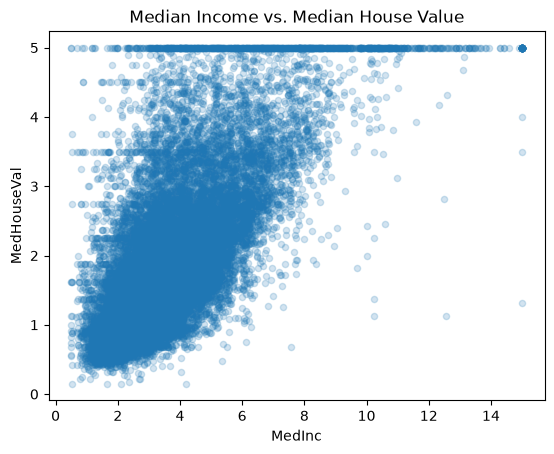

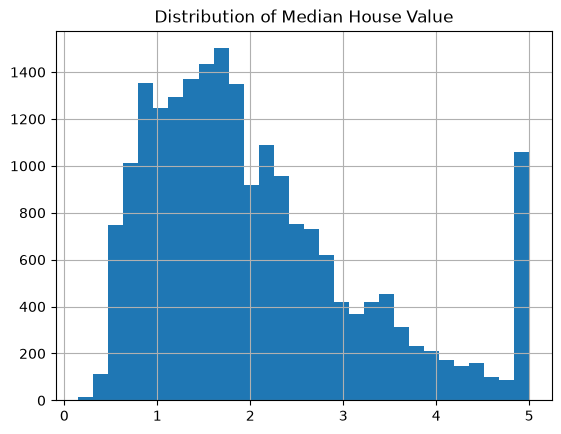

In [10]:
import matplotlib.pyplot as plt
print(housing.describe())
print(housing.isnull().sum().sum())     # 0 - no missing values
 
corr = housing.corr()
print(corr['MedHouseVal'].sort_values(ascending=False))
 
housing.plot.scatter(x='MedInc', y='MedHouseVal', alpha=0.2)
plt.title('Median Income vs. Median House Value')
plt.show()
 
housing['MedHouseVal'].hist(bins=30)
plt.title('Distribution of Median House Value')
plt.show()


In [11]:
from sklearn.model_selection import train_test_split
 
X_h = housing[['MedInc']]              # start with a single feature
y_h = housing['MedHouseVal']
Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X_h, y_h, test_size=0.2, random_state=1)


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Wine dataset
wine = load_wine()

X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target, name="target")

# Basic EDA
print("Dataset shape:", X_wine.shape)
print("\nFirst 5 rows:")
print(X_wine.head())

print("\nSummary statistics:")
print(X_wine.describe())

print("\nMissing values:")
print(X_wine.isnull().sum())

print("\nTarget distribution:")
print(y_wine.value_counts().sort_index())

# Train/test split
Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_wine,
    y_wine,
    test_size=0.2,
    random_state=42,
    stratify=y_wine
)

print("\nTraining shape:", Xw_train.shape)
print("Testing shape:", Xw_test.shape)

# Scaling
scaler_wine = StandardScaler()

Xw_train_scaled = scaler_wine.fit_transform(Xw_train)
Xw_test_scaled = scaler_wine.transform(Xw_test)

print("\nScaled training shape:", Xw_train_scaled.shape)
print("Scaled testing shape:", Xw_test_scaled.shape)

print("\nScaled training mean:")
print(np.round(Xw_train_scaled.mean(axis=0), 3))

print("\nScaled training standard deviation:")
print(np.round(Xw_train_scaled.std(axis=0), 3))

Dataset shape: (178, 13)

First 5 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_dilu

Slope: 0.42055457383802924  Intercept: 0.4472183362106785
Equation: MedHouseVal = 0.421 * MedInc + 0.447


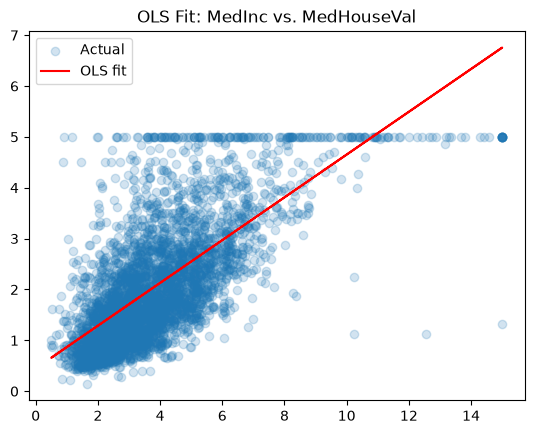

In [26]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
 
ols = LinearRegression()
ols.fit(Xh_train, yh_train)
print('Slope:', ols.coef_[0], ' Intercept:', ols.intercept_)
print('Equation: MedHouseVal =', round(ols.coef_[0], 3), '* MedInc +', round(ols.intercept_, 3))
 
plt.scatter(Xh_test, yh_test, alpha=0.2, label='Actual')
plt.plot(Xh_test, ols.predict(Xh_test), color='red', label='OLS fit')
plt.legend(); plt.title('OLS Fit: MedInc vs. MedHouseVal')
plt.show()


Inliers: 10016  Outliers: 6496
RANSAC slope: 0.5690172928029587  intercept: -0.40251885119207986


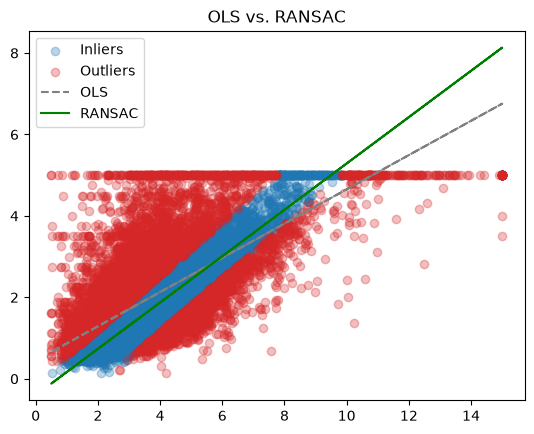

In [27]:
from sklearn.linear_model import RANSACRegressor
 
ransac = RANSACRegressor(LinearRegression(), random_state=1)
ransac.fit(Xh_train, yh_train)
 
inlier_mask = ransac.inlier_mask_
print('Inliers:', inlier_mask.sum(), ' Outliers:', (~inlier_mask).sum())
print('RANSAC slope:', ransac.estimator_.coef_[0], ' intercept:', ransac.estimator_.intercept_)
 
plt.scatter(Xh_train[inlier_mask], yh_train[inlier_mask], color='tab:blue', alpha=0.3, label='Inliers')
plt.scatter(Xh_train[~inlier_mask], yh_train[~inlier_mask], color='tab:red', alpha=0.3, label='Outliers')
plt.plot(Xh_test, ols.predict(Xh_test), color='gray', linestyle='--', label='OLS')
plt.plot(Xh_test, ransac.predict(Xh_test), color='green', label='RANSAC')
plt.legend(); plt.title('OLS vs. RANSAC')
plt.show()


OLS: RMSE=0.832, R2=0.472
RANSAC: RMSE=0.921, R2=0.353


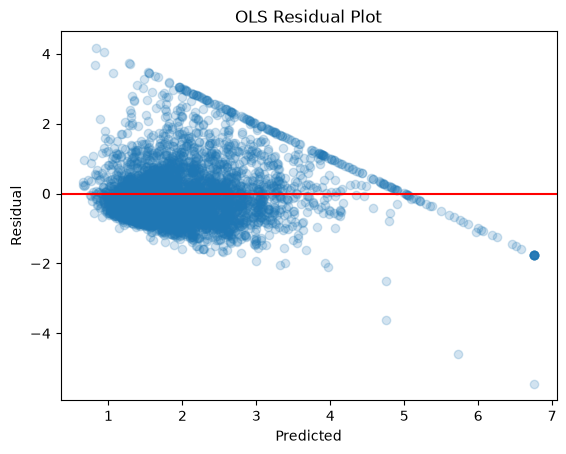

In [28]:
from sklearn.metrics import mean_squared_error, r2_score
 
for name, model in [('OLS', ols), ('RANSAC', ransac)]:
    preds = model.predict(Xh_test)
    rmse = mean_squared_error(yh_test, preds) ** 0.5
    r2 = r2_score(yh_test, preds)
    print(f'{name}: RMSE={rmse:.3f}, R2={r2:.3f}')
 
residuals = yh_test - ols.predict(Xh_test)
plt.scatter(ols.predict(Xh_test), residuals, alpha=0.2)
plt.axhline(0, color='red')
plt.xlabel('Predicted'); plt.ylabel('Residual')
plt.title('OLS Residual Plot')
plt.show()



Gradient descent w: 0.7955141442312055  b: 2.0773506404917774


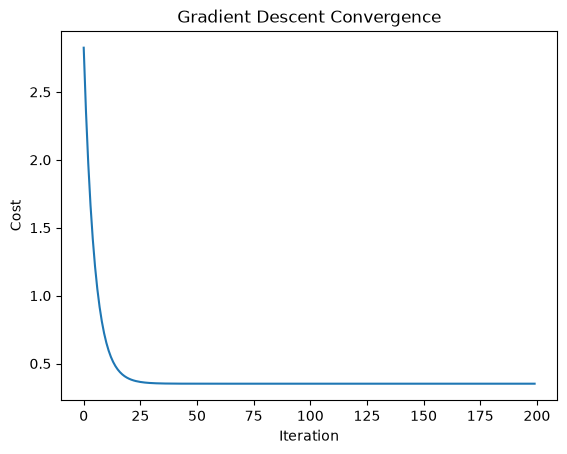

In [29]:
import numpy as np
def gradient_descent(X, y, lr=0.1, n_iter=200):
    X = X.values.flatten()
    y = y.values
    m = len(y)
    w, b = 0.0, 0.0
    cost_history = []
    for i in range(n_iter):
        y_pred = w * X + b
        dw = (1 / m) * np.sum((y_pred - y) * X)
        db = (1 / m) * np.sum(y_pred - y)
        w -= lr * dw
        b -= lr * db
        cost_history.append((1 / (2 * m)) * np.sum((y_pred - y) ** 2))
    return w, b, cost_history
 
Xh_train_std = (Xh_train - Xh_train.mean()) / Xh_train.std()   # scale first!
w, b, costs = gradient_descent(Xh_train_std, yh_train, lr=0.1, n_iter=200)
print('Gradient descent w:', w, ' b:', b)
 
plt.plot(costs)
plt.xlabel('Iteration'); plt.ylabel('Cost')
plt.title('Gradient Descent Convergence')
plt.show()


In [30]:
import pandas as pd
 
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target
print(df.shape)
print(cancer.target_names)   # ['malignant' 'benign']


(569, 31)
['malignant' 'benign']


target
1    357
0    212
Name: count, dtype: int64
0


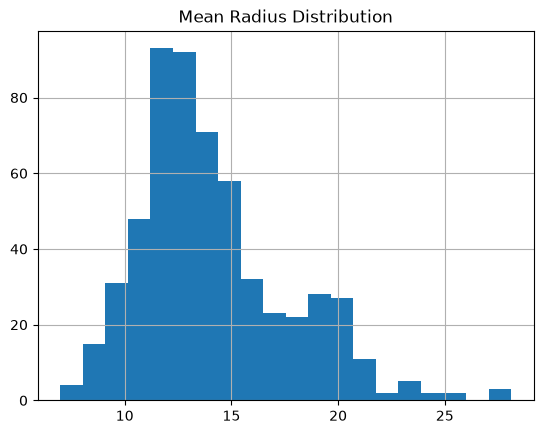

In [31]:
import matplotlib.pyplot as plt
 
print(df['target'].value_counts())     # class balance
print(df.isnull().sum().sum())         # missing values
 
df['mean radius'].hist(bins=20)
plt.title('Mean Radius Distribution')
plt.show()


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
 
X = df.drop(columns='target')
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y)   # split
 
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)                  # scale


Log-loss: 0.04954746484437864
Test accuracy: 0.9912280701754386


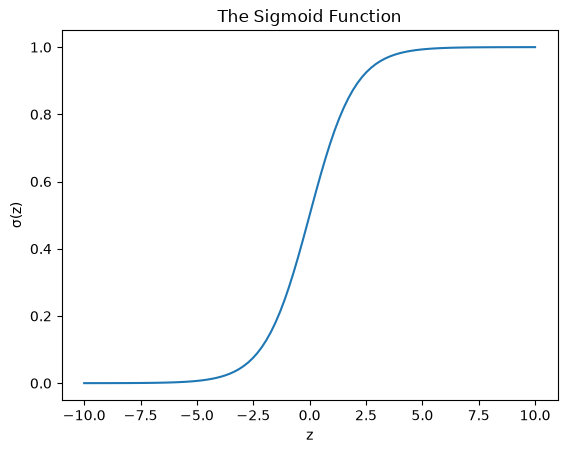

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
 
logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train_std, y_train)
 
probs = logreg.predict_proba(X_test_std)[:, 1]
print('Log-loss:', log_loss(y_test, probs))
print('Test accuracy:', logreg.score(X_test_std, y_test))
 
z = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-z))
plt.plot(z, sigmoid)
plt.title('The Sigmoid Function')
plt.xlabel('z'); plt.ylabel('σ(z)')
plt.show()


L1 nonzero coefficients: 13 of 30
L2 nonzero coefficients: 30 of 30


c:\Users\MUREED\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\MUREED\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\MUREED\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default

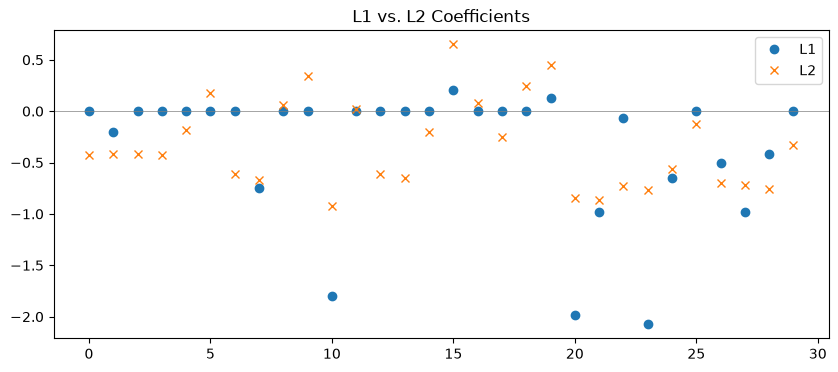

In [34]:
l1_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, max_iter=5000)
l1_model.fit(X_train_std, y_train)
 
l2_model = LogisticRegression(penalty='l2', C=0.5, max_iter=5000)
l2_model.fit(X_train_std, y_train)
 
print('L1 nonzero coefficients:', np.sum(l1_model.coef_[0] != 0), 'of', len(l1_model.coef_[0]))
print('L2 nonzero coefficients:', np.sum(l2_model.coef_[0] != 0), 'of', len(l2_model.coef_[0]))
 
plt.figure(figsize=(10, 4))
plt.plot(l1_model.coef_[0], 'o', label='L1')
plt.plot(l2_model.coef_[0], 'x', label='L2')
plt.axhline(0, color='gray', linewidth=0.5)
plt.legend(); plt.title('L1 vs. L2 Coefficients'); plt.show()


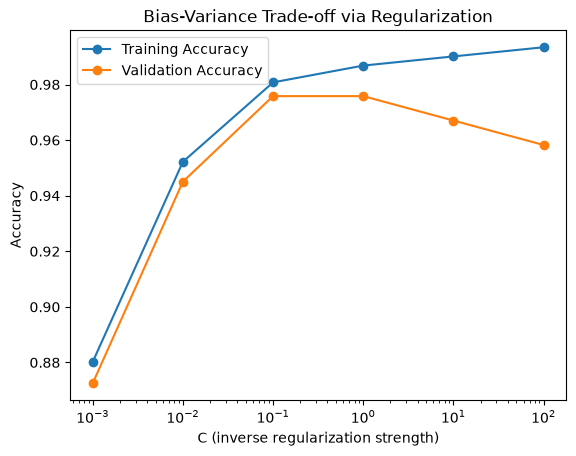

In [35]:
from sklearn.model_selection import validation_curve
 
C_range = [0.001, 0.01, 0.1, 1, 10, 100]
train_scores, val_scores = validation_curve(
    LogisticRegression(max_iter=5000), X_train_std, y_train,
    param_name='C', param_range=C_range, cv=5)
 
plt.plot(C_range, train_scores.mean(axis=1), marker='o', label='Training Accuracy')
plt.plot(C_range, val_scores.mean(axis=1), marker='o', label='Validation Accuracy')
plt.xscale('log')
plt.xlabel('C (inverse regularization strength)'); plt.ylabel('Accuracy')
plt.legend(); plt.title('Bias-Variance Trade-off via Regularization')
plt.show()


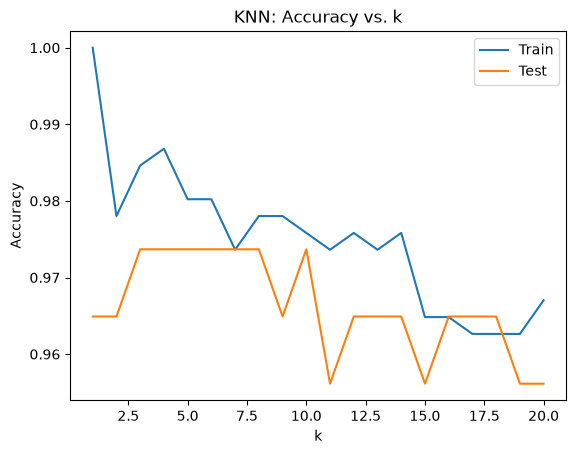

Best k: 3


In [36]:
from sklearn.neighbors import KNeighborsClassifier
 
k_range = range(1, 21)
train_acc, test_acc = [], []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_std, y_train)
    train_acc.append(knn.score(X_train_std, y_train))
    test_acc.append(knn.score(X_test_std, y_test))
 
plt.plot(k_range, train_acc, label='Train')
plt.plot(k_range, test_acc, label='Test')
plt.xlabel('k'); plt.ylabel('Accuracy'); plt.legend()
plt.title('KNN: Accuracy vs. k')
plt.show()
 
best_k = list(k_range)[np.argmax(test_acc)]
print('Best k:', best_k)


Logistic Regression (L2)
              precision    recall  f1-score   support

   malignant       1.00      0.98      0.99        42
      benign       0.99      1.00      0.99        72

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



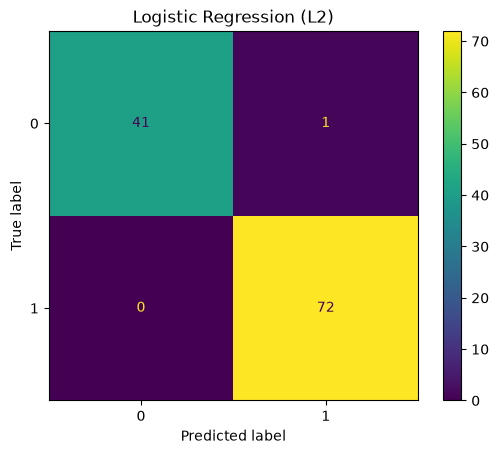

KNN
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        42
      benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



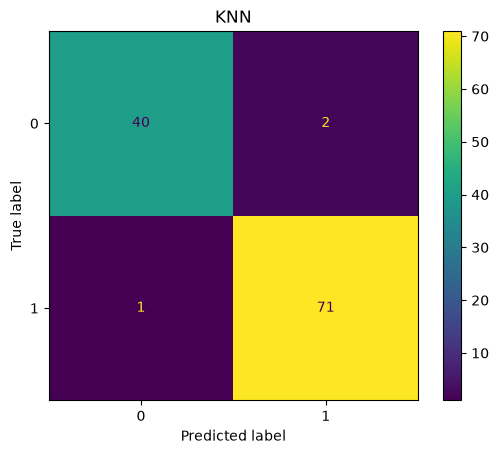

In [37]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
 
final_knn = KNeighborsClassifier(n_neighbors=best_k).fit(X_train_std, y_train)
 
for name, model in [('Logistic Regression (L2)', l2_model), ('KNN', final_knn)]:
    preds = model.predict(X_test_std)
    print(name)
    print(classification_report(y_test, preds, target_names=cancer.target_names))
    ConfusionMatrixDisplay.from_predictions(y_test, preds)
    plt.title(name)
    plt.show()



In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Wine dataset
wine = load_wine()

X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target, name="target")

# Basic EDA
print("Dataset shape:", X_wine.shape)
print("\nFirst 5 rows:")
print(X_wine.head())

print("\nSummary statistics:")
print(X_wine.describe())

print("\nMissing values:")
print(X_wine.isnull().sum())

print("\nTarget distribution:")
print(y_wine.value_counts().sort_index())

# Train/test split
Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_wine,
    y_wine,
    test_size=0.2,
    random_state=42,
    stratify=y_wine
)

print("\nTraining shape:", Xw_train.shape)
print("Testing shape:", Xw_test.shape)

# Scaling
scaler_wine = StandardScaler()

Xw_train_scaled = scaler_wine.fit_transform(Xw_train)
Xw_test_scaled = scaler_wine.transform(Xw_test)

print("\nScaled training shape:", Xw_train_scaled.shape)
print("Scaled testing shape:", Xw_test_scaled.shape)

print("\nScaled training mean:")
print(np.round(Xw_train_scaled.mean(axis=0), 3))

print("\nScaled training standard deviation:")
print(np.round(Xw_train_scaled.std(axis=0), 3))

Dataset shape: (178, 13)

First 5 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_dilu